In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos de estaciones en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Temperatura/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,1,VAEXJOE,SE,+56:52:00,+014:48:00,166
1,2,FALUN,SE,+60:37:00,+015:37:00,160
2,3,STENSELE,SE,+65:04:00,+017:09:59,325
3,4,LINKOEPING,SE,+58:24:00,+015:31:59,93
4,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
...,...,...,...,...,...,...
9698,27950,E6 SEFRIVATNET,NO,+65:15:11,+013:18:55,308
9699,27951,E6 HANSMYRAN,NO,+65:12:07,+013:22:45,368
9700,27952,FV659 REMMEFJELL,NO,+62:32:26,+006:28:45,124
9701,27953,E75 DOMEN,NO,+70:20:02,+031:01:26,103


In [3]:
#Filtrado de datos para Italia
metadata_IT=metadata[metadata.CN=='IT']
metadata_IT

,STAID,STANAME,CN,LAT,LON,HGHT
130,169,BOLOGNA,IT,+44:30:00,+011:20:45,53
131,170,FERRARA,IT,+44:49:57,+011:37:15,15
132,173,MILAN,IT,+45:28:18,+009:11:21,150
133,174,BRINDISI,IT,+40:37:59,+017:55:59,10
134,175,CAGLIARI,IT,+39:13:59,+009:03:00,21
...,...,...,...,...,...,...
9682,27908,MONDEVAL DI SOPRA (SELVA DI CADORE),IT,+46:27:51,+012:06:03,2175
9683,27909,PASSO CIMABANCHE,IT,+46:37:14,+012:11:02,1532
9684,27910,ROVINA DI CANCIA (BORCA DI CADORE Q1335),IT,+46:26:13,+012:14:34,1335
9685,27911,MONTE GRANDE (TEOLO),IT,+45:21:42,+011:40:22,465


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_IT['LAT'] = metadata_IT['LAT'].apply(dms_a_decimal)
metadata_IT['LON'] = metadata_IT['LON'].apply(dms_a_decimal)
metadata_IT

,STAID,STANAME,CN,LAT,LON,HGHT
130,169,BOLOGNA,IT,44.500000,11.345833,53
131,170,FERRARA,IT,44.832500,11.620833,15
132,173,MILAN,IT,45.471667,9.189167,150
133,174,BRINDISI,IT,40.633056,17.933056,10
134,175,CAGLIARI,IT,39.233056,9.050000,21
...,...,...,...,...,...,...
9682,27908,MONDEVAL DI SOPRA (SELVA DI CADORE),IT,46.464167,12.100833,2175
9683,27909,PASSO CIMABANCHE,IT,46.620556,12.183889,1532
9684,27910,ROVINA DI CANCIA (BORCA DI CADORE Q1335),IT,46.436944,12.242778,1335
9685,27911,MONTE GRANDE (TEOLO),IT,45.361667,11.672778,465


In [6]:
#Carga de mapas para obtener mapa de España
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
italia = world[world["name"] == "Italy"] #Mapa de Italia

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_IT['LON'], metadata_IT['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_IT, geometry=estaciones, crs="EPSG:4326") 

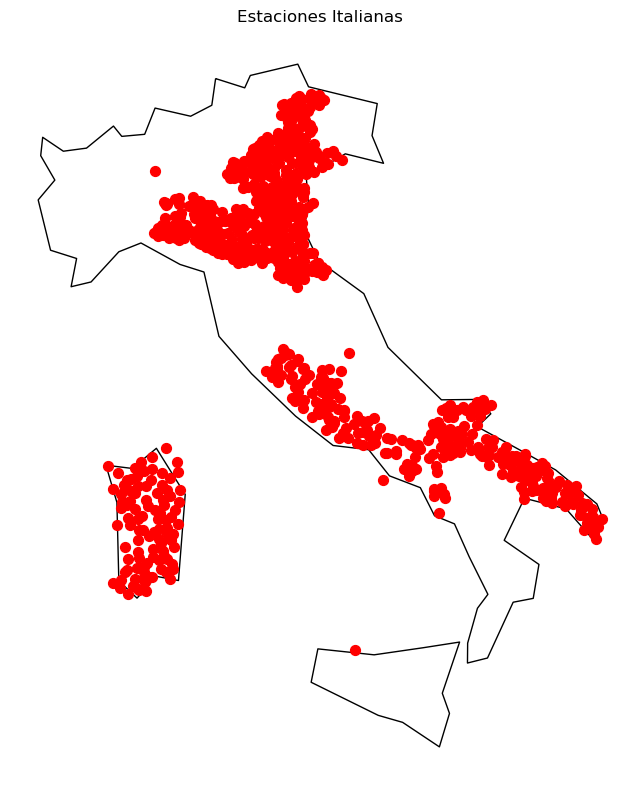

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones italianas
lista_estaciones_italianas=metadata_IT.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='TG_STAID000000'
station_i=station[:-len(str(lista_estaciones_italianas[0]))]+str(lista_estaciones_italianas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Temperatura/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9) & (data.DATE<'2025-01-01')]
data_unif=data.loc[:,['DATE','TG']]
data_unif.set_index('DATE', inplace=True)
data_unif

,TG
DATE,
2008-01-01,29
2008-01-02,34
2008-01-03,17
2008-01-04,21
2008-01-05,39
...,...
2024-12-27,31
2024-12-28,43
2024-12-29,45


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_italianas[1:]:
    station='TG_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Temperatura/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9) & (data.DATE<'2025-01-01')]
    df=data.loc[:,['DATE','TG']]
    df.set_index('DATE', inplace=True)
    data_unif['TG '+str(i)]=df

data_unif

,TG,TG 170,TG 173,TG 174,TG 175,TG 176,TG 177,TG 380,TG 381,TG 854,...,TG 27902,TG 27904,TG 27905,TG 27906,TG 27907,TG 27908,TG 27909,TG 27910,TG 27911,TG 27912
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,29,25.0,62.0,56.0,85.0,51.0,17.0,NaN,138.0,-30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-02,34,16.0,56.0,51.0,90.0,38.0,16.0,NaN,146.0,-6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-03,17,5.0,35.0,57.0,120.0,88.0,7.0,NaN,135.0,-21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-04,21,34.0,38.0,94.0,132.0,95.0,30.0,NaN,132.0,-8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-05,39,45.0,55.0,127.0,113.0,123.0,44.0,NaN,134.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,31,32.0,NaN,135.0,106.0,NaN,61.0,45.0,NaN,3.0,...,71.0,18.0,-11.0,72.0,62.0,39.0,53.0,43.0,76.0,64.0
2024-12-28,43,53.0,NaN,132.0,88.0,NaN,70.0,39.0,NaN,18.0,...,106.0,31.0,7.0,74.0,48.0,40.0,54.0,41.0,71.0,88.0
2024-12-29,45,56.0,NaN,117.0,96.0,NaN,51.0,47.0,NaN,28.0,...,95.0,36.0,14.0,102.0,54.0,41.0,50.0,49.0,79.0,89.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen mas de un 2% de datos faltantes y se renombra la primera estación 
# con el ID de estación
d=data_unif.dropna(thresh=round(data_unif.shape[0]*0.98), axis=1) 
d=d.rename({'TG':'TG '+str(lista_estaciones_italianas[0])},axis=1)
d

,TG 169,TG 170,TG 174,TG 1736,TG 11611,TG 17530,TG 17588,TG 17607,TG 17627,TG 17629,...,TG 17865,TG 17878,TG 21785,TG 25641,TG 25989,TG 26059,TG 26062,TG 27785,TG 27786,TG 27796
DATE,,,,,,,,,,,,,,,,,,,,,
2008-01-01,29,25.0,56.0,35.0,14,1,21.0,-13,-2.0,0.0,...,26.0,25.0,15.0,85.0,48.0,69.0,41.0,-13.0,14,14
2008-01-02,34,16.0,51.0,22.0,17,-2,9.0,0,3.0,8.0,...,26.0,16.0,10.0,90.0,40.0,42.0,34.0,0.0,17,17
2008-01-03,17,5.0,57.0,30.0,6,4,17.0,-2,7.0,8.0,...,25.0,5.0,26.0,120.0,58.0,96.0,53.0,-2.0,6,6
2008-01-04,21,34.0,94.0,30.0,38,35,29.0,26,34.0,25.0,...,23.0,34.0,28.0,132.0,77.0,101.0,72.0,26.0,38,38
2008-01-05,39,45.0,127.0,51.0,48,50,46.0,38,41.0,31.0,...,38.0,45.0,54.0,113.0,90.0,112.0,83.0,38.0,48,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,31,32.0,135.0,76.0,25,27,56.0,20,25.0,21.0,...,43.0,32.0,74.0,102.0,103.0,105.0,94.0,20.0,25,19
2024-12-28,43,53.0,132.0,91.0,43,39,71.0,36,39.0,35.0,...,54.0,53.0,76.0,80.0,116.0,81.0,103.0,37.0,43,38
2024-12-29,45,56.0,117.0,77.0,37,32,70.0,35,36.0,35.0,...,49.0,56.0,63.0,87.0,107.0,83.0,99.0,34.0,37,36


In [13]:
# Estaciones italianas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_IT[metadata_IT.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
130,169,BOLOGNA,IT,44.500000,11.345833,53
131,170,FERRARA,IT,44.832500,11.620833,15
133,174,BRINDISI,IT,40.633056,17.933056,10
726,1736,RIMINI,IT,44.058333,12.579444,7
4169,11611,SERMIDE (SP 91),IT,45.016667,11.290000,10
4286,17530,BERRA,IT,44.967778,11.895556,3
4320,17588,CESENATICO_PORTO,IT,44.206389,12.400833,1
4330,17607,DIAMANTINA,IT,44.885556,11.511667,5
4342,17627,GAIBANELLA,IT,44.768889,11.662500,3
4344,17629,GALLO,IT,44.723889,11.545278,21


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

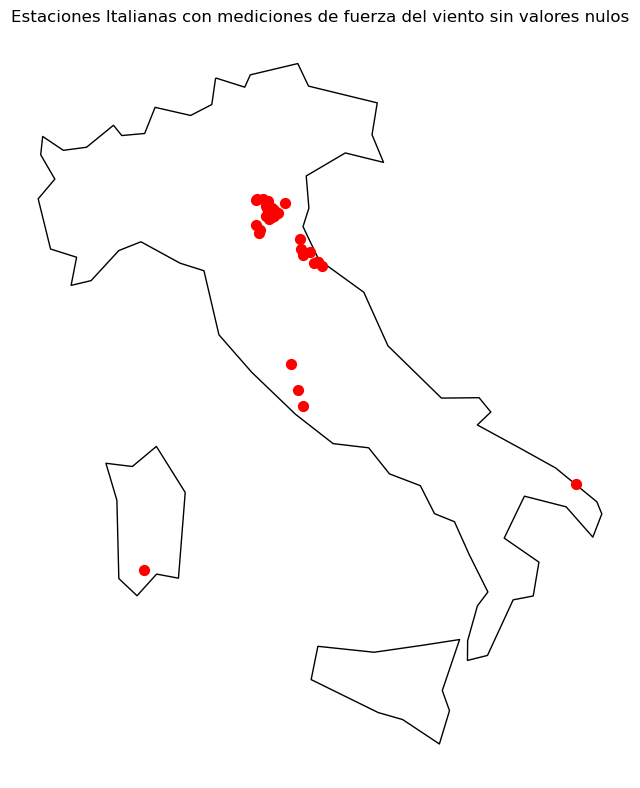

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_it=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_it['LON'],mt_it['LAT'],mt_it['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_IT=mt_it[mt_it.STAID.isin(ww)]
mt_IT

,STAID,STANAME,CN,LAT,LON,HGHT
130,169,BOLOGNA,IT,44.500000,11.345833,53
133,174,BRINDISI,IT,40.633056,17.933056,10
726,1736,RIMINI,IT,44.058333,12.579444,7
4169,11611,SERMIDE (SP 91),IT,45.016667,11.290000,10
8143,25641,FLUMINIMANNU_A_DECIMOMANNU,IT,39.307500,8.953056,8
8263,25989,BRACCIANO,IT,42.073056,12.147778,251


In [18]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_IT['LON'], mt_IT['LAT'])] 
puntos = gpd.GeoDataFrame(mt_IT, geometry=estaciones, crs="EPSG:4326") 

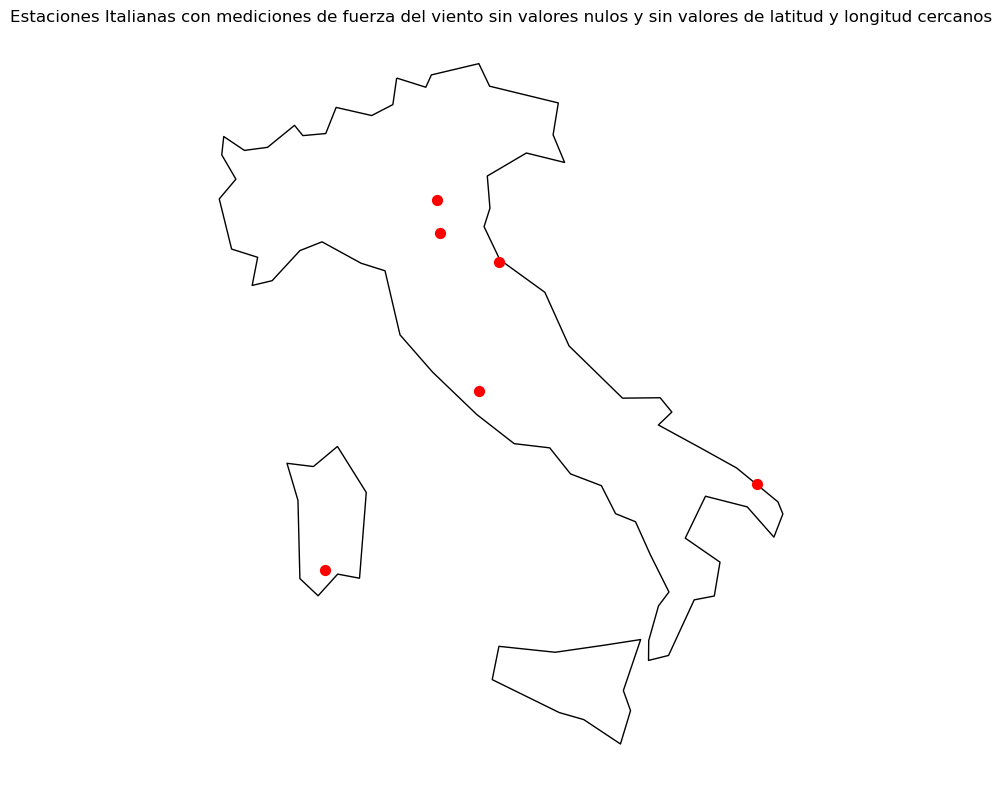

In [19]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
italia.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Italianas con mediciones de fuerza del viento sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [20]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['TG '+str(i) for i in mt_IT.STAID.to_list()]]
data=data.resample('MS').mean()
data

,TG 169,TG 174,TG 1736,TG 11611,TG 25641,TG 25989
DATE,,,,,,
2008-01-01,59.935484,102.516129,63.129032,53.387097,107.096774,79.806452
2008-02-01,67.241379,94.655172,65.034483,60.517241,107.965517,75.206897
2008-03-01,106.774194,130.193548,104.838710,94.225806,127.129032,92.193548
2008-04-01,138.633333,148.533333,138.433333,133.200000,154.500000,124.300000
2008-05-01,184.935484,190.935484,180.419355,187.096774,190.451613,167.000000
...,...,...,...,...,...,...
2024-08-01,260.709677,281.225806,281.354839,261.064516,283.000000,280.419355
2024-09-01,196.066667,236.633333,217.333333,198.600000,235.633333,215.344828
2024-10-01,161.709677,204.133333,181.064516,161.903226,210.161290,183.193548


In [21]:
#Cálculo de la media para cada mes en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'TG'},axis=1)
a

,TG
DATE,
2008-01-01,77.645161
2008-02-01,78.436782
2008-03-01,109.225806
2008-04-01,139.600000
2008-05-01,183.473118
...,...
2024-08-01,274.629032
2024-09-01,216.601916
2024-10-01,183.694265


In [24]:
#Exportación de datos mensuales de temperatura en Italia
a.to_csv('temperatura_mensual_ita.csv',index=True,encoding='utf-8')

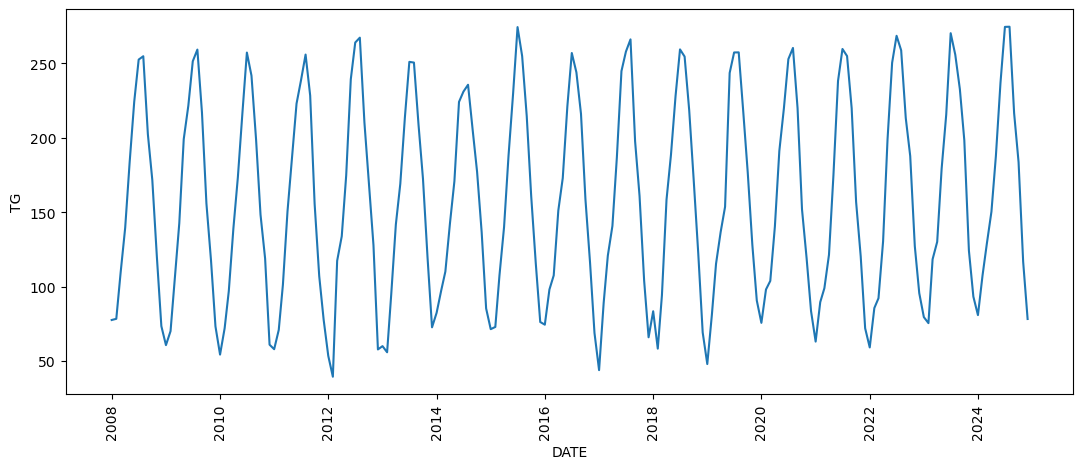

In [23]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.TG)
plt.xticks(rotation=90)
plt.show()